# Metagenomic Analysis: The Global Gut Microbiome
### PA 1 – Applied Digital Life Sciences – Digital Health
**Authors:** Ajna Binaki, Dario Filippone, Peter Pan, Naruto, Gojo, Sukuna

## Introduction
Write text here.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

Primary data were retrieved from the Microbiome Atlas (https://www.microbiomeatlas.org). We integrated demographic metadata (sampleID.csv) with microbial abundance profiles (vect_atlas.csv) by performing a join on the unique identifier sample.ID. The resulting consolidated dataset, combined_data.csv, served as the basis for the next steps.

In [2]:
path_metadata      = '../data/raw/Human_atlas/sampleID.csv'
path_microbiome_raw = '../data/raw/Human_atlas/vect_atlas.csv'

metadata      = pd.read_csv(path_metadata)
microbiome_raw = pd.read_csv(path_microbiome_raw, index_col=0)

microbiome    = microbiome_raw.transpose()
combined_data = pd.merge(metadata, microbiome, left_on='sample.ID', right_index=True, how='inner')

print(f"Dataset shape: {combined_data.shape[0]} samples, {combined_data.shape[1]} columns")
combined_data.to_csv('../data/processed/01_combined_data.csv', index=False)

display(combined_data.head())

Dataset shape: 6014 samples, 2004 columns


,sample.ID,BioProject,type,Age,Gender,BMI,Geography,Sequencer,MgsRichness,GeneRichness,...,msp_2176,msp_2178,msp_2180,msp_2191,msp_2195,msp_2196,msp_2207,msp_2209,msp_2210,msp_2211
0,ERS608599,PRJEB7774,Disease,64.0,Male,29.0,Austria,Illumina HiSeq 2000,184,563013,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ERS608499,PRJEB7774,Control,68.0,Male,32.0,Austria,Illumina HiSeq 2000,265,686859,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ERS608489,PRJEB7774,Control,60.0,Female,22.0,Austria,Illumina HiSeq 2000,228,616715,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ERS608554,PRJEB7774,Disease,70.0,Male,34.0,Austria,Illumina HiSeq 2000,236,628862,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ERS608521,PRJEB7774,Control,68.0,Male,23.0,Austria,Illumina HiSeq 2000,254,627031,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Demographics

Prior to microbial analysis, it is essential to characterize the distribution of demographic variables. Furthermore, the geographic origin of the study cohorts must be evaluated to determine sample sizes per country. This metadata is critical for identifying and adjusting for batch effects.

### 3.1 Healthy vs Disease

The analysis has been restricted to healthy samples to eliminate interference from disease-state microbiomes. As a first step, the distribution of sample sizes was evaluated across the remaining cohorts.

In [3]:
combined_data["type"] = combined_data["type"].astype("category")

healthy_data = combined_data[combined_data["type"] == "Control"]
disease_data = combined_data[combined_data["type"] == "Disease"]
healthy_data.to_csv('../data/processed/02_healthy_data.csv', index=False)
disease_data.to_csv('../data/processed/03_disease_data.csv', index=False)

print(f"Total samples:  {len(combined_data)}")
print(f"  Healthy:      {len(healthy_data)}")
print(f"  Disease:      {len(disease_data)}")

Total samples:  6014
  Healthy:      3292
  Disease:      2713


In [4]:
# Samples per country, split by health status
country_type = (
    combined_data
    .groupby(["Geography", "type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .assign(Total=lambda df: df.sum(axis=1))
    .sort_values("Total", ascending=False)
)

# print("--- Samples per Country ---")
# print(country_type.to_string())

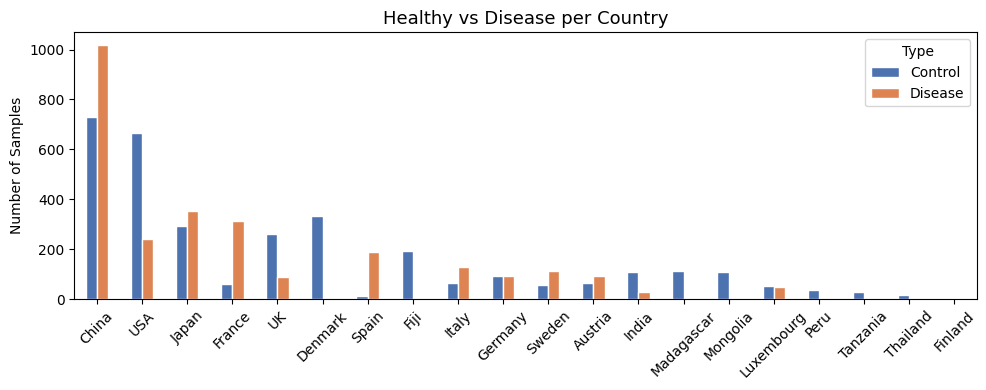

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

country_type[["Control", "Disease"]].plot(
    kind="bar", ax=ax,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white"
)

ax.set_title("Healthy vs Disease per Country", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type")
plt.tight_layout()
plt.show()

The data shows that sample distribution varies by country. Some countries lack disease samples entirely, while others have more disease samples than healthy ones. Focusing only on the 3,292 healthy samples provides a strong foundation for the analysis described in the introduction.

### 3.2 Analysis of healthy study cohort samples

Following the initial comparison of both groups, the distribution of the healthy cohort must be examined separately. This provides a clearer view of the study population and informs the methodology for the subsequent analysis.

In [6]:
# Examining how many study cohorts there are
count_study_cohorts = healthy_data['BioProject'].nunique()

count_study_cohorts

35

The dataset comprises a total of 35 unique study cohorts. Their geographic distribution is illustrated in the following bar plot, highlighting the number of cohorts associated with each country.

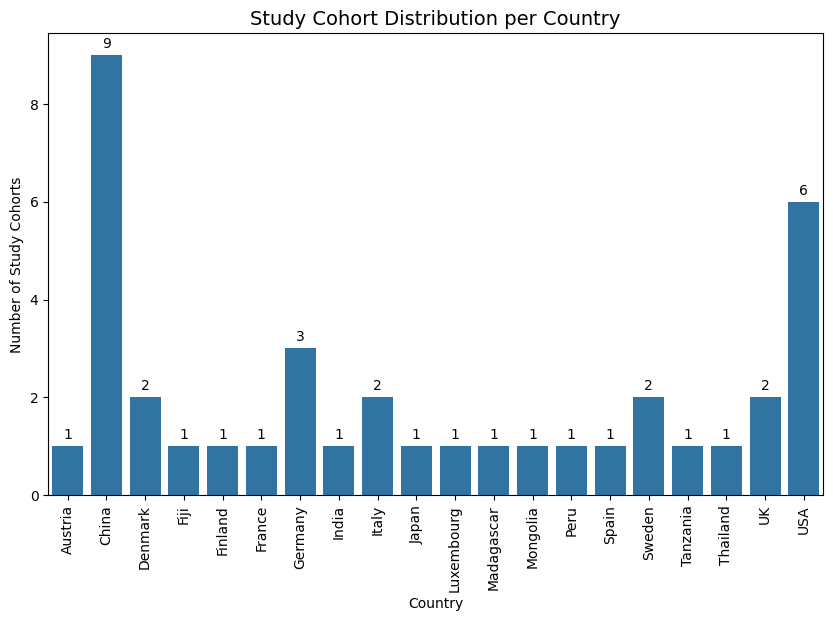

In [7]:
count_study = healthy_data.groupby("Geography")["BioProject"].nunique().reset_index()

# Creating the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=count_study, x="Geography", y="BioProject")

# Add labels
ax.bar_label(ax.containers[0], padding=3)

# # 4. Formatting
plt.title("Study Cohort Distribution per Country", fontsize=14)
plt.ylabel("Number of Study Cohorts")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.show()



While most countries are represented by a single study cohort, a discrepancy exists between the total number of unique cohorts (35) and the cumulative count shown in the geographic distribution (39). This indicates that certain study cohorts are multi-centered, spanning across multiple countries.

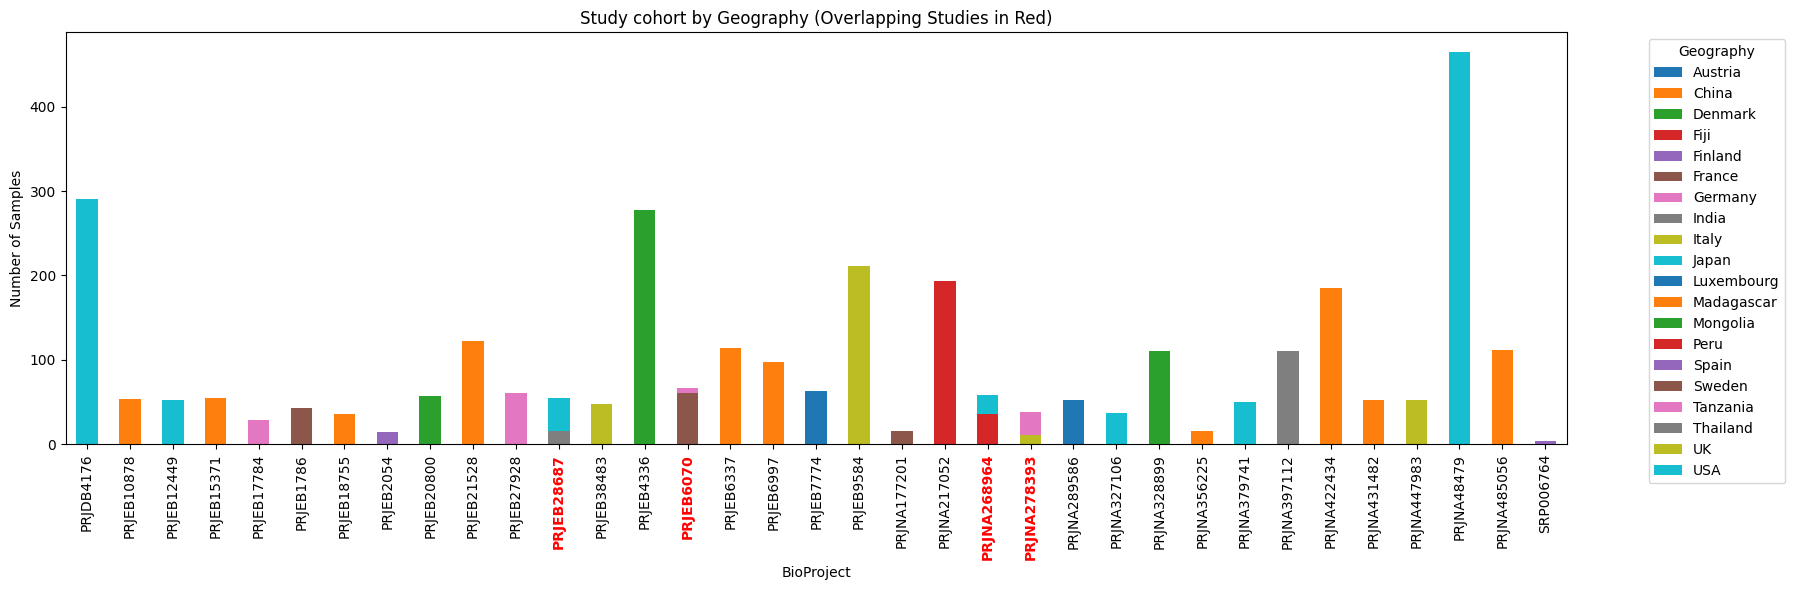

In [8]:
# Create the pivot
study_distribution = healthy_data.groupby(["BioProject", "Geography"]).size().unstack(fill_value=0)

# 1. Identify which projects have more than one country (the overlaps)
# We count how many non-zero entries exist in each row
is_overlapping = (study_distribution > 0).sum(axis=1) > 1

# 2. Plot as usual
ax = study_distribution.plot(kind="bar", stacked=True, figsize=(18, 6))

# 3. Loop through the x-axis labels and color the overlapping ones
for label in ax.get_xticklabels():
    project_id = label.get_text()
    if is_overlapping[project_id]:
        label.set_color("red")
        label.set_weight("bold")

plt.ylabel("Number of Samples")
plt.title("Study cohort by Geography (Overlapping Studies in Red)")
plt.xticks(rotation=90)
plt.legend(title="Geography", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The following analysis provides a detailed view of the sample distribution across the four multi-center study cohorts. This breakdown illustrates the geographic composition of each cohort and the corresponding sample sizes per country.

In [9]:
# 1. Define the list of target BioProjects
target_projects = ["PRJEB28687", "PRJEB6070", "PRJNA278393", "PRJNA268964"]

# 2. Filter the data and create the pivot table
# This identifies exactly how many samples belong to each project per country
overlap_counts = (
    healthy_data[healthy_data["BioProject"].isin(target_projects)]
    .groupby(["BioProject", "Geography"])
    .size()
    .unstack(fill_value=0)
)

# 3. Display the resulting table
print("Sample counts per country for target cohorts:")
display(overlap_counts)



Sample counts per country for target cohorts:


Geography,France,Germany,Italy,Peru,Tanzania,Thailand,USA
BioProject,,,,,,,
PRJEB28687,0,0,0,0,0,15,40
PRJEB6070,61,5,0,0,0,0,0
PRJNA268964,0,0,0,36,0,0,22
PRJNA278393,0,0,11,0,27,0,0


PRJEB28687: Study made in the US, people from Thailand are immigrants in the US. Study found out that "migration from a non-Western country to the U.S. is associated with immediate loss of gut microbiome diversity and function" (https://pubmed.ncbi.nlm.nih.gov/25432777/)

PRJEB6070: "All samples were paired-end sequenced with 100-bp read length at the Genomics Core Facility, European Molecular Biology Laboratory, Heidelberg" (https://pmc.ncbi.nlm.nih.gov/articles/PMC4299606/)

PRJNA268964: Samples frozen until arriving in Oklahoma. (https://www.nature.com/articles/ncomms7505#Sec10)

PRJNA278393: No methods mentioned, it looks like samples have been analyzed in Italy (https://pubmed.ncbi.nlm.nih.gov/25981789/)

Lastly, the demographic features were analyzed to detect variations and identify missing data. 

In [10]:
missing_values = healthy_data.iloc[:,:10].isna().sum()

display(missing_values)

sample.ID         0
BioProject        0
type              0
Age             604
Gender          399
BMI             833
Geography         0
Sequencer         0
MgsRichness       0
GeneRichness      0
dtype: int64

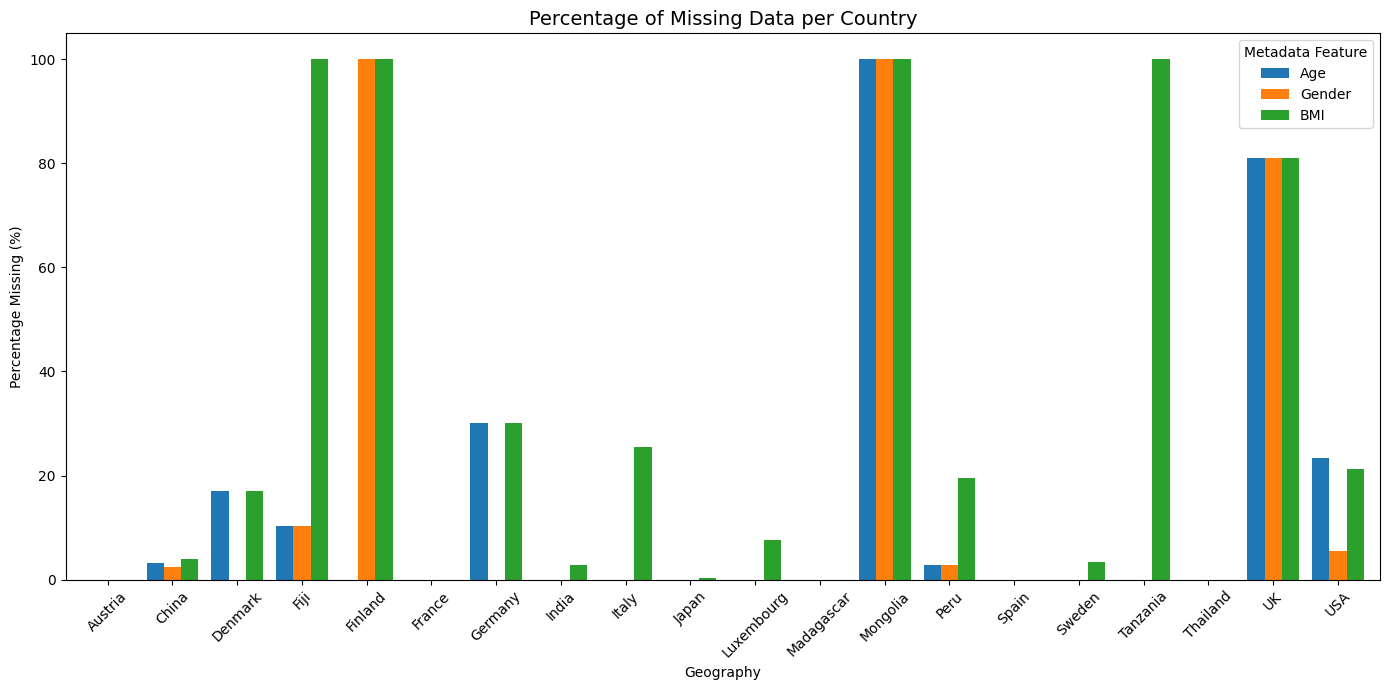

In [11]:
# Calculate percentage of missing values (isna().mean() * 100)
missing_pct = healthy_data.groupby("Geography")[["Age", "Gender", "BMI"]].apply(lambda x: x.isna().mean() * 100)

missing_pct.plot(kind="bar", figsize=(14, 7), width=0.8)
plt.title("Percentage of Missing Data per Country", fontsize=14)
plt.ylabel("Percentage Missing (%)")
plt.ylim(0, 105) # Keeps the scale consistent
plt.xticks(rotation=45)
plt.legend(title="Metadata Feature")
plt.tight_layout()
plt.show()

**Microbiome Sample Summary**

From all samples available in the Microbiome Data Atlas, 3,292 samples from healthy individuals were selected, providing a solid starting point for analysis. These samples represent 35 study cohorts, with most countries corresponding to a single cohort. However, four cohorts (Bioproject IDs: PRJEB28687, PRJEB6070, PRJNA268964, PRJNA278393) include participants from two different countries.
Analysis of the three demographic features — Age, Gender, and BMI — revealed the following missing data patterns:

- Fiji: BMI entries missing
- Finland: Gender and BMI entries missing
- Mongolia: Age, Gender, and BMI entries missing
- Tanzania: BMI entries missing
- United Kingdom: ~80% of entries missing for all three features

All other countries either have complete demographic data or are missing less than 30% of entries.

# 4. Preprocessing

Before applying analytical methods or machine learning pipelines, raw metagenomic data must undergo rigorous preprocessing to account for its unique mathematical properties. Bacterial abundance tables are inherently **sparse** and **compositional**, with a hight zero-inflation. This sparsity arises because individual samples only contain a specific subset of the global microbial diversity, and limited sequencing depth, often referred to as **sampling effort**, can lead to a failure in capturing rare taxa. [Knights et al. (2018)](../Papers/Knight2018BestPracticesforAnalyzingMicrobiomes.pdf)

## Metadata and Feature Description

| Column        | Description |
|--------------|------------|
| `sample.ID`  | Unique identifier per sample. |
| `BioProject` | Source study; used to identify and mitigate potential **batch effects**. |
| `type`       | Binary classification: Control (healthy) vs. Disease. |
| `Age` / `Gender` | Demographic covariates used for cohort matching. |
| `BMI`        | Body Mass Index; the primary phenotypic variable for obesity analysis. |
| `Geography`  | Country of origin; a major driver of microbial variance. |
| `MgsRichness`| Alpha-diversity metric (Species Richness) per sample. |
| `msp_XXXX`   | Metagenomic Species Pangenome (MSP) relative abundance. |

---

# Preprocessing Workflow

To ensure a robust comparison between geographical cohorts and phenotypes, the following pipeline was implemented based on established best practices according to [Knights et al. (2018)](../Papers/Knight2018BestPracticesforAnalyzingMicrobiomes.pdf) and [Gregory B. gloor(2017)](../Papers/GregoryBGloor2017.pdf)

## 1. Quality and Prevalence Filtering

Following the recommendation to control for technical variation and sequencing errors, filtering was performed prior to normalization.

- **Sample Filtering (Richness):** Following the recommendation to exclude samples (rarefraction) with insufficient sampling effort, we excluded samples in the lowest 5th percentile of richness to remove technical artifacts. This ensures that only samples with sufficient "sampling effort" are compared, as extremely low richness typically indicates technical artifacts or poor DNA yield. [Knights et al. (2018), Chapter 3](../Papers/Knight2018BestPracticesforAnalyzingMicrobiomes.pdf)

- **Taxa Filtering (Prevalence):** MSPs present in fewer than 10% of samples were removed. This step is crucial because most apparent sequence diversity in marker gene and metagenomic data often arises from sequencing errors. [Knights et al. (2018), Chapter 3](../Papers/Knight2018BestPracticesforAnalyzingMicrobiomes.pdf). Additionaly, this step reduces sparsity, which makes it more suited for downstream ML applications and by focusing on stable microbial signatures we gain more predictible and reproducible insights.


## 2. Normalization: Total Sum Scaling (TSS)

To account for varying sequencing depths across different library preparations, counts were normalized to relative abundances. Each sample was divided by its row sum so that the features sum to 1.0:

$$
x_{rel} = \frac{x_i}{\sum x_i}
$$

While this makes samples comparable regardless of original scale, it reinforces the compositional nature of the data, where features are no longer independent. In this setup, an increase in one species' proportion mathematically forces others to decrease, even if their true abundance is stable. This artificial dependency often triggers spurious correlations that can mislead standard statistical analyses. [Gregory B. gloor(2017)](../Papers/GregoryBGloor2017.pdf)

## 3. Transformation: Centered Log-Ratio (CLR)

To move the data from the Aitchison simplex into Euclidean space, we applied the **Centered Log-Ratio (CLR)** transformation. This transformation is "compositionally aware" and allows for the application of standard statistical tools like PCA and Random Forest without the biases inherent in proportional data.

The CLR is calculated as:

$$
CLR(x) = \left[ \ln \frac{x_1}{g(x)}, \dots, \ln \frac{x_n}{g(x)} \right]
$$

where $g(x)$ represents the geometric mean of the abundances within the sample. [Gregory B. gloor(2017)](../Papers/GregoryBGloor2017.pdf)

## 4. Validation of Library Size Independence

While the CLR transformation is a robust tool for handling compositionality, it can remain sensitive to library size. The total sum of bacterial counts (sampling effort) per sample. Especially in sparse datasets. If this technical factor is not addressed, the most significant patterns in the data may reflect sequencing depth rather than true biology, potentially leading to Type 1 Errors (False Positives) when comparing cohorts. [Dennis E. te Beest et al. 2021)](../Papers/Preprocessing/DennisEteBeest2021.pdf)


### Validation Steps

Due to this, we performed a Log-Ratio PCA diagnostic:

- **Metric:** We calculated the correlation (Pearson's R) between the log₁₀-transformed library sizes and the first principal component (PC1).
- **Success Criterion:** A low correlation and a non-linear "cloud" distribution in the diagnostic plot confirm that the biological signal is successfully decoupled from sequencing depth.

In [12]:
# --- Configuration & Constants ---
RICHNESS_Q = 0.05
PREVALENCE_T = 0.10

# Initial Filtering: Extract Healthy Cohort
# Frop Type column
healthy_df = healthy_data.drop(columns=["type"]).copy()

# Identify Column Groups
msp_cols = [c for c in healthy_df.columns if c.startswith('msp')]
meta_cols = [c for c in healthy_df.columns if not c.startswith('msp')]

# Sample Filtering (Richness)
# Calculate richness for each sample (number of MSPs with abundance > 0)
richness = healthy_df[msp_cols].gt(0).sum(axis=1)
richness_threshold = richness.quantile(RICHNESS_Q)

filtered_df = healthy_df[richness >= richness_threshold].copy()

# Pravalence Filtering, Remove MSPs that are present in less than 10% of samples
prevalence = (filtered_df[msp_cols] > 0).mean()
keep_msps = prevalence[prevalence >= PREVALENCE_T].index.tolist()

# Assembly of Dataset
final_data = filtered_df[meta_cols + keep_msps]

# Save output
final_data.to_csv('../data/processed/04_filtered_healthy_data.csv', index=False)

# Checking the results
print(f"Shape:    {final_data.shape}")
print(f"Taxa:     {len(keep_msps)} kept from {len(msp_cols)}")
print(f"Min Prev: {(final_data[keep_msps] > 0).mean().min():.1%}")
print(f"Richness: {final_data[keep_msps].gt(0).sum(axis=1).min()} to {final_data[keep_msps].gt(0).sum(axis=1).max()}")



Shape:    (3128, 609)
Taxa:     596 kept from 1990
Min Prev: 10.0%
Richness: 53 to 388


In [13]:
# Normalization (TSS)
normalized_df = final_data.copy()
normalized_df[keep_msps] = normalized_df[keep_msps].div(normalized_df[keep_msps].sum(axis=1), axis=0)
normalized_df.to_csv('../data/processed/05_normalized_healthy_data.csv', index=False)

# Calculatiing percentage of 0s after normalization
zero_percentage = (normalized_df[keep_msps] == 0).mean().mean()
print(f"Percentage of zeros after normalization: {zero_percentage:.1%}")

Percentage of zeros after normalization: 66.6%


In [14]:
# CLR Transformation
clr_df = normalized_df.copy()

log_data = np.log(clr_df[keep_msps].replace(0, 1e-6))
clr_df[keep_msps] = log_data.sub(log_data.mean(axis=1), axis=0)
clr_df.to_csv('../data/processed/06_clr_healthy_data.csv', index=False)

In [15]:
# Quick Data Integrity Check
print(f" Data Checks for CLR-Transformed Data:")
print(f"NaN Values: {clr_df[keep_msps].isna().sum().sum()}")
print(f"Zero Values: {(clr_df[keep_msps] == 0).sum().sum()}")
print(f"Dimensions: {clr_df.shape[0]} Samples x {len(keep_msps)} MSPs")

 Data Checks for CLR-Transformed Data:
NaN Values: 0
Zero Values: 0
Dimensions: 3128 Samples x 596 MSPs


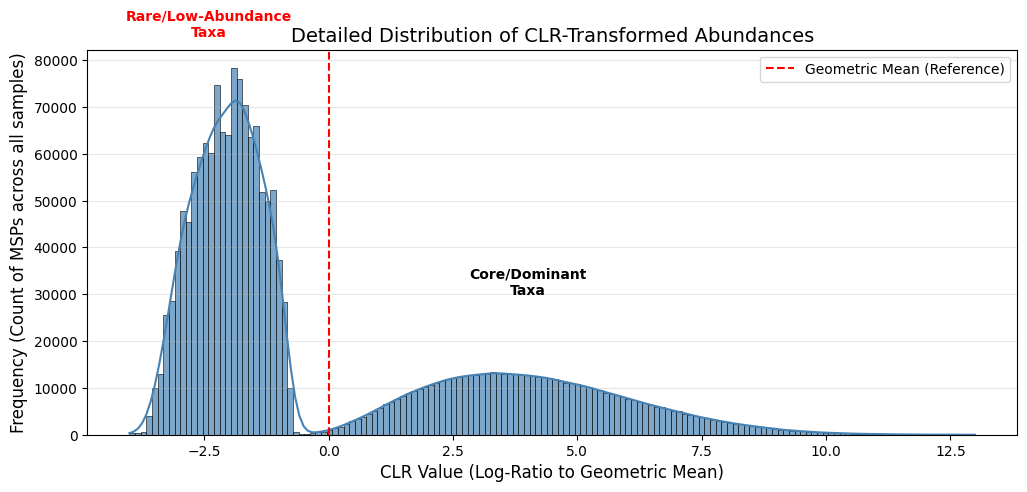

In [16]:
# plotting the distribution of CLR values across all samples and MSPs
plt.figure(figsize=(12, 5))

# bin count
sns.histplot(clr_df[keep_msps].values.flatten(), bins=150, kde=True, color="steelblue", alpha=0.7)

# 0 Line
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label="Geometric Mean (Reference)")

# Informative Text Labels
plt.text(-2.4, 85000, 'Rare/Low-Abundance\nTaxa', horizontalalignment='center', color='red', fontweight='bold')
plt.text(4, 30000, 'Core/Dominant\nTaxa', horizontalalignment='center', color='black', fontweight='bold')

plt.title("Detailed Distribution of CLR-Transformed Abundances", fontsize=14)
plt.xlabel("CLR Value (Log-Ratio to Geometric Mean)", fontsize=12)
plt.ylabel("Frequency (Count of MSPs across all samples)", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()

## Summary and Data Readiness

The preprocessing pipeline has successfully transformed the raw metagenomic counts into a statistically robust dataset. By combining quality filtering, TSS normalization, and CLR transformation, we have addressed the inherent sparsity and compositionality of the microbiome data.

### Interpretation of the CLR Distribution

The **"Detailed Distribution"** plot above provides a clear visual validation of our transformation:

- The two distinct "mountains" reveal the two functional worlds of our dataset. The **Left Peak** represents the rare biosphere and zeros, while the **Right Peak** captures the core, dominant taxa.
- **The Zero-Line (0):** Taxa to the right of the red dashed line are more abundant than the geometric mean of their respective samples, while those to the left are less abundant.
- **Data Symmetry:** The transformation has effectively transformed the data to a **symmetric log-ratio scale** suitable for linear models and machine learning.